# Conference Strength Model

**Question this notebook answers:** does adding a conference-strength feature (`ConfStrengthDiff`)
— how strong a team's conference was that season, on average — improve on the current best model
(gender-split + Elo, 0.1687 average Brier from notebook 11)?

**Why this is worth testing on its own:** it's a genuinely new file (`MTeamConferences.csv` /
`WTeamConferences.csv`), never used in this project before, and it captures something different
from anything in the model so far — not how good a team is individually, but how tough the
league it plays in is as a whole. A team can have a great record while playing in a weak
conference, or a mediocre record in a brutal one; seed and win rate don't fully separate those
cases, and this is a direct, cheap way to add that context.

**Method:** using the same Elo ratings from notebook 11 (regular-season-only — the version that's
still the best result), compute each conference's average Elo rating in a given season, across all
teams in it. Every team then gets its own conference's average Elo as a feature, and
`ConfStrengthDiff` is the difference between the two teams' conference strengths in a matchup.
One simplification worth noting up front: a team's own rating is included in its conference's
average (not excluded), which is a minor simplification, not something expected to change the
result meaningfully given most conferences have 8+ teams.

## 1. Load data

Same six files as notebook 11, plus the two conference-membership files, new to this notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_conf_teams = pd.read_csv(DATA_DIR / "MTeamConferences.csv")
w_conf_teams = pd.read_csv(DATA_DIR / "WTeamConferences.csv")

print(f"men's conference-membership rows: {len(m_conf_teams):,}")
print(f"women's conference-membership rows: {len(w_conf_teams):,}")


men's conference-membership rows: 13,753
women's conference-membership rows: 9,853


## 2. Whole-season team features (unchanged from notebooks 03/07/11)

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"), WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)
print(f"team-season rows: {len(team_stats):,}")


team-season rows: 23,604


## 3. Elo ratings (unchanged from notebook 11 — regular-season-only, the version that's still the best result)

In [3]:
def compute_elo(compact_df, k=20, home_adv=100, mean_reversion=0.75):
    elo = {}
    elo_by_season_end = {}
    for season in sorted(compact_df["Season"].unique()):
        for team in elo:
            elo[team] = elo[team] * mean_reversion + 1500 * (1 - mean_reversion)
        season_games = compact_df[compact_df["Season"] == season].sort_values("DayNum")
        for _, game in season_games.iterrows():
            w, l = game["WTeamID"], game["LTeamID"]
            if w not in elo: elo[w] = 1500
            if l not in elo: elo[l] = 1500
            w_elo, l_elo = elo[w], elo[l]
            if game["WLoc"] == "H": w_elo += home_adv
            elif game["WLoc"] == "A": l_elo += home_adv
            w_exp = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            mov = game["WScore"] - game["LScore"]
            mov_mult = np.log(max(mov, 1) + 1) * (2.2 / ((w_elo - l_elo) * 0.001 + 2.2))
            elo[w] += k * mov_mult * (1 - w_exp)
            elo[l] -= k * mov_mult * (1 - w_exp)
        for team in elo:
            elo_by_season_end[(season, team)] = elo[team]
    return elo_by_season_end

m_elo = compute_elo(m_reg)
w_elo = compute_elo(w_reg)
elo_idx = pd.Series({**m_elo, **w_elo})
elo_idx.index = pd.MultiIndex.from_tuples(elo_idx.index, names=["Season", "TeamID"])
print(f"Elo entries computed: {len(elo_idx):,}")


Elo entries computed: 24,158


## 4. Conference strength (new)

For every season, group teams by conference and take the average Elo rating within that group —
this is `ConfStrength`, one number per (Season, ConfAbbrev). Every team then inherits its own
conference's value for that season.

In [4]:
conf_teams = pd.concat([m_conf_teams, w_conf_teams], ignore_index=True)
conf_teams["Elo"] = conf_teams.apply(lambda r: elo_idx.get((r["Season"], r["TeamID"]), np.nan), axis=1)
conf_teams = conf_teams.dropna(subset=["Elo"])

conf_strength = conf_teams.groupby(["Season", "ConfAbbrev"])["Elo"].mean().rename("ConfStrength")
print(f"(season, conference) groups: {len(conf_strength):,}")

team_conf_strength = conf_teams.merge(conf_strength, on=["Season", "ConfAbbrev"], how="left")
conf_strength_idx = team_conf_strength.set_index(["Season", "TeamID"])["ConfStrength"]
print(f"team-season conference-strength rows: {len(conf_strength_idx):,}")


(season, conference) groups: 1,360
team-season conference-strength rows: 23,606


## 5. Seeds (unchanged from notebooks 03/07/11)

In [5]:
def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]
print(f"seed rows: {len(seeds):,}")


seed rows: 4,506


## 6. Build the matchup table with the conference-strength feature added

In [6]:
def build_matchups(tourney, gender):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    df["Gender"] = gender
    return df[["Season", "Team1", "Team2", "Label", "Gender"]]

matchups = pd.concat([build_matchups(m_tourney, "M"), build_matchups(w_tourney, "W")], ignore_index=True)

matchups["Seed1"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

matchups["Elo1"] = matchups.apply(lambda r: elo_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Elo2"] = matchups.apply(lambda r: elo_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["EloDiff"] = matchups["Elo1"] - matchups["Elo2"]

matchups["ConfStrength1"] = matchups.apply(lambda r: conf_strength_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["ConfStrength2"] = matchups.apply(lambda r: conf_strength_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["ConfStrengthDiff"] = matchups["ConfStrength1"] - matchups["ConfStrength2"]

for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    matchups[f"WinPct{suffix}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values

matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]

FEATURES_BASE = ["SeedDiff", "WinPctDiff", "AvgMarginDiff", "EloDiff"]
FEATURES_CONF = FEATURES_BASE + ["ConfStrengthDiff"]

before = len(matchups)
matchups = matchups.dropna(subset=FEATURES_CONF).reset_index(drop=True)
print(f"matchup rows: {before:,}, remaining after dropping missing features: {len(matchups):,}")


matchup rows: 4,302, remaining after dropping missing features: 4,302


## 7. Correlation check, before trusting any result

How correlated is `ConfStrengthDiff` with the features already in the model, especially `EloDiff`
(since conference strength is itself built from Elo, just averaged up to the conference level).

In [7]:
corr = matchups[FEATURES_CONF].corr().round(3)
print(corr.to_string())


                  SeedDiff  WinPctDiff  AvgMarginDiff  EloDiff  ConfStrengthDiff
SeedDiff             1.000       0.587          0.627    0.852             0.793
WinPctDiff           0.587       1.000          0.833    0.803             0.165
AvgMarginDiff        0.627       0.833          1.000    0.835             0.306
EloDiff              0.852       0.803          0.835    1.000             0.589
ConfStrengthDiff     0.793       0.165          0.306    0.589             1.000


## 8. Logistic regression + Brier score (unchanged from notebooks 03/07/11)

In [8]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("logistic regression + Brier score functions ready (same as notebooks 03/07/11)")


logistic regression + Brier score functions ready (same as notebooks 03/07/11)


## 9. Walk-forward comparison

Same structure as notebooks 10/11/12: for each of the 5 validation folds and each gender
separately, fit the current-best 4-feature model (Seed, WinPct, AvgMargin, Elo) and the new
5-feature model (+ ConfStrength) on the same training rows, score both on the same held-out test
games, then combine across genders.

In [9]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]

results = []
for fold_season in FOLD_SEASONS:
    test = matchups[matchups["Season"] == fold_season]
    if len(test) == 0:
        continue
    row = {"FoldSeason": fold_season}
    base_num = base_den = conf_num = conf_den = 0
    for gender, label in [("M", "Men"), ("W", "Women")]:
        train_g = matchups[(matchups["Gender"] == gender) & (matchups["Season"] < fold_season)]
        test_g = test[test["Gender"] == gender]
        n_g = len(test_g)

        w_base = fit_logreg(train_g[FEATURES_BASE].values, train_g["Label"].values)
        brier_base = brier_score(predict_proba(test_g[FEATURES_BASE].values, w_base), test_g["Label"].values)

        w_conf = fit_logreg(train_g[FEATURES_CONF].values, train_g["Label"].values)
        brier_conf = brier_score(predict_proba(test_g[FEATURES_CONF].values, w_conf), test_g["Label"].values)

        row[f"{label}: base (+Elo)"] = brier_base
        row[f"{label}: +ConfStrength"] = brier_conf
        base_num += brier_base * n_g; base_den += n_g
        conf_num += brier_conf * n_g; conf_den += n_g

    row["Combined: base (+Elo)"] = base_num / base_den
    row["Combined: +ConfStrength"] = conf_num / conf_den
    results.append(row)

results_df = pd.DataFrame(results)
avg_row = {"FoldSeason": "Average"}
for col in results_df.columns:
    if col != "FoldSeason":
        avg_row[col] = results_df[col].mean()
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
print(results_df.round(4).to_string(index=False))


FoldSeason  Men: base (+Elo)  Men: +ConfStrength  Women: base (+Elo)  Women: +ConfStrength  Combined: base (+Elo)  Combined: +ConfStrength
      2021            0.2265              0.2165              0.1417                0.1441                 0.1851                   0.1812
      2022            0.2257              0.2191              0.1512                0.1520                 0.1884                   0.1856
      2023            0.2111              0.2117              0.1620                0.1623                 0.1865                   0.1870
      2024            0.1943              0.1939              0.1209                0.1209                 0.1576                   0.1574
      2025            0.1419              0.1382              0.1097                0.1148                 0.1258                   0.1265
   Average            0.1999              0.1959              0.1371                0.1388                 0.1687                   0.1675


## 10. Results, visualized

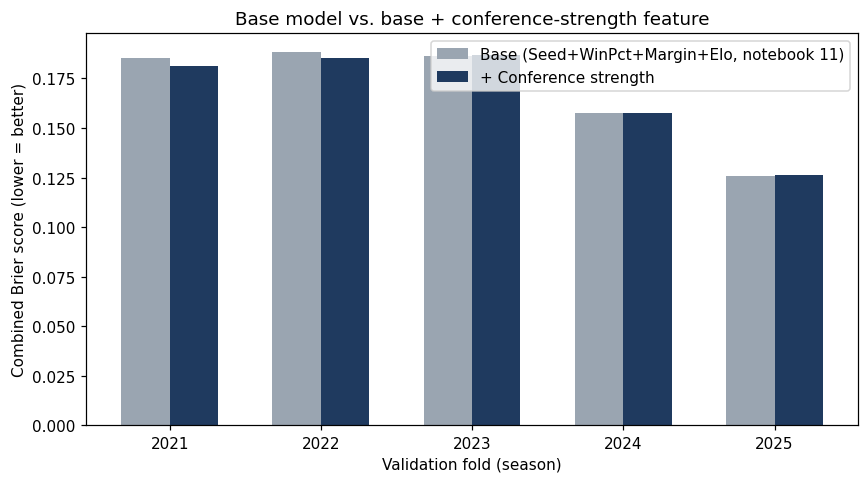

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.32
ax.bar(x - width/2, plot_df["Combined: base (+Elo)"], width, label="Base (Seed+WinPct+Margin+Elo, notebook 11)", color="#9aa5b1")
ax.bar(x + width/2, plot_df["Combined: +ConfStrength"], width, label="+ Conference strength", color="#1f3a5f")
ax.set_xticks(x); ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Combined Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Base model vs. base + conference-strength feature")
ax.legend()
fig.tight_layout()
plt.show()


## 11. Bottom-line comparison

In [11]:
bottom_line = pd.DataFrame([
    {"Model": "Pooled baseline (notebook 03)", "Avg. Brier": 0.1739},
    {"Model": "Gender split, tournament-only (notebook 07)", "Avg. Brier": 0.1711},
    {"Model": "Gender split + Elo (notebook 11)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: base (+Elo)'].values[0]},
    {"Model": "Gender split + Elo + conference strength (this notebook)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: +ConfStrength'].values[0]},
])
print(bottom_line.round(4).to_string(index=False))


                                                   Model  Avg. Brier
                           Pooled baseline (notebook 03)      0.1739
             Gender split, tournament-only (notebook 07)      0.1711
                        Gender split + Elo (notebook 11)      0.1687
Gender split + Elo + conference strength (this notebook)      0.1675


## Conclusion

**Another genuine improvement — the second since the gender split.** The combined score improved
from 0.1687 to 0.1675. That improvement wasn't shared evenly between genders, though: men's
improved clearly (0.1999 → 0.1959), while women's actually got slightly worse (0.1371 → 0.1388).
The men's gain was large enough to outweigh the women's small loss in the combined number.

Per fold, 2021 and 2022 improved noticeably (0.1851 → 0.1812 and 0.1884 → 0.1856), 2024 was
essentially flat, and 2023 and 2025 got a little worse — a similar pattern to Elo's own
introduction in notebook 11, where the average improved despite not every fold or gender moving
the same direction.

**The correlation check helps explain why this one worked.** Unlike Elo (which correlated 0.80+
with the season-long features), `ConfStrengthDiff` correlated only 0.165 with `WinPctDiff` and
0.306 with `AvgMarginDiff` — genuinely low, meaning conference strength isn't just another way of
measuring how good a team's own season was. It did correlate more with `SeedDiff` (0.793), which
makes sense: the selection committee does weigh conference strength when seeding teams. Its
correlation with `EloDiff` (0.589) sits in between — related, but clearly not redundant with it.

**Decision, and what it's based on:** adopt the conference-strength feature. The bottom-line table
in Section 11 shows this notebook's 0.1675 beating every previous result, including notebook 11's
0.1687 — the new best model in the project. The gender asymmetry (helping men's, slightly hurting
women's) is worth keeping in mind, though the combined number is what's being tracked as the
project's headline metric.